# Computer Networks Project 2
## NAPALM-Based Network Automation & Configuration Simulation using Python
William Miller, Marc Pham

## Introduction  (Will, rewrite this AI)

This project is a Python-based simulation of network automation inspired by the NAPALM framework, designed to replicate key operational workflows such as configuration management, device provisioning, state inspection, and reporting without requiring access to physical hardware or virtual environments like GNS3. A central component of the system is a mock `driver` class that mimics the behavior of a NAPALM device driver, providing familiar methods such as loading candidate configurations, committing changes, and retrieving interface or device state. This abstraction allows users to experiment with realistic network automation workflows even when real infrastructure is unavailable, making it particularly useful for learning, prototyping, or rapid testing.

Instead of interacting with live routers, users define network topologies and device configurations through structured JSON files, which are then interpreted inside a Jupyter Notebook to dynamically construct a graph-based representation of the network. This design enables configuration-driven topology generation, where the relationship between interfaces, subnets, and devices is automatically inferred rather than manually specified. To enhance understanding of how these configurations affect overall network behavior, the system generates both static and interactive visualizations, alongside connectivity analyses that evaluate which devices can communicate with each other. A reporting module further summarizes device states and configuration outcomes, providing clear feedback on provisioning success. Together, these components create an accessible simulation environment that mirrors real-world network automation practices while remaining lightweight and fully software-based.


## Motivation  (Will, rewrite this AI)

The motivation for this project comes from the gap between learning network automation concepts and actually being able to experiment with them in a practical environment. Tools like NAPALM and automation frameworks are widely used in industry, but they often require access to real network devices, virtual labs, or platforms such as GNS3, which can be time-consuming to set up or inaccessible for many students and early learners. This project addresses that limitation by providing a lightweight, fully software-based simulation that mirrors the core behaviors of NAPALM, allowing users to explore automation workflows without needing physical infrastructure.

For network designers, the system offers a safe environment to test configuration changes, understand how interface and subnet definitions shape topology, and visualize the downstream effects of design decisions before deployment. For students, it serves as a hands-on learning tool that reinforces key networking concepts such as routing adjacency, subnet inference, configuration states, and device provisioning logic. By implementing a mock NAPALM driver, users gain insight into how real automation frameworks operate under the hood ⸺ particularly how configurations are staged, compared, committed, or discarded across devices. This bridges the gap between theoretical networking knowledge and practical automation workflows.

From a broader perspective, the project reflects trends in the networking industry toward software-defined infrastructure and automation-first operations. As organizations increasingly rely on tools like NAPALM, Ansible, and Netmiko to manage large-scale environments, there is growing demand for engineers who understand both networking fundamentals and automation logic. This simulation helps develop those skills in an accessible way, lowering the barrier to entry and accelerating learning. In this sense, the project not only supports individual education but also aligns with market needs by preparing learners for modern, automation-driven networking roles.


## Methodology

Import the following modules and libraries.

In [63]:
from napalm import get_network_driver
import time
import json
import os
from IPython.display import display, HTML, IFrame
import networkx as nx
import matplotlib.pyplot as plt
import ipaddress
from pyvis.network import Network
import dash
from dash import html
import dash_cytoscape as cyto
import numpy as np
from matplotlib.patches import Patch
from itertools import product

In [2]:
class driver:
    def __init__(self, hostname):
        self.hostname = hostname
        self.running_config = []
        self.candidate_config = []

        self.interfaces = {
            "eth0": {"is_up": True, "ip": None},
            "eth1": {"is_up": True, "ip": None},
        }

In [3]:
def load_merge_candidate(self, config):
    print(f"\n[{self.hostname}] load_merge_candidate()")
    self.candidate_config = config

driver.load_merge_candidate = load_merge_candidate

In [4]:
def compare_config(self):
    print(f"[{self.hostname}] compare_config()")

    diff = []

    for line in self.candidate_config:
        if line not in self.running_config:
            diff.append(f"+ {line}")

    for line in self.running_config:
        if line not in self.candidate_config:
            diff.append(f"- {line}")

    return "\n".join(diff)

driver.compare_config = compare_config

In [5]:
def commit_config(self):
    print(f"[{self.hostname}] commit_config()")

    self.running_config = self.candidate_config.copy()

    current_interface = None

    for line in self.candidate_config:
        parts = line.strip().split()

        if len(parts) == 0:
            continue

        if parts[0] == "interface":
            current_interface = parts[1]

            if current_interface not in self.interfaces:
                self.interfaces[current_interface] = {
                    "is_up": True,
                    "ip": None
                }

        elif len(parts) >= 3 and parts[0] == "ip" and parts[1] == "address":
            if current_interface:
                self.interfaces[current_interface]["ip"] = parts[2]

def discard_config(self):
    print(f"[{self.hostname}] discard_config()")
    self.candidate_config = []
    
driver.commit_config = commit_config
driver.discard_config = discard_config

In [6]:
def get_facts(self):
    return {
        "hostname": self.hostname,
        "vendor": "mock_napalm_driver",
        "config_lines": len(self.running_config),
    }

def get_interfaces(self):
    return self.interfaces

driver.get_facts = get_facts
driver.get_interfaces = get_interfaces

In [7]:
# ==============================
# CONFIG LOADER
# ==============================
def load_device_configs(filename):
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()  # fallback for notebooks/interactive mode

    file_path = os.path.join(base_dir, filename)

    with open(file_path, "r") as f:
        return json.load(f)

def build_config(device_data):
    config = []

    config.append(f"hostname {device_data['hostname']}")

    for intf, ip in device_data["interfaces"].items():
        config.append(f"interface {intf}")
        if ip:
            config.append(f"ip address {ip}")

    return config    

In [8]:
def provision_devices(devices, config_file):
    configs = load_device_configs(config_file)

    print("\n===== PROVISIONING DEVICES =====")

    for name, data in configs.items():
        device = devices[name]

        config_lines = build_config(data)

        device.load_merge_candidate(config_lines)

        diff = device.compare_config()

        print(f"\n[{name}] CONFIG DIFF:")
        print(diff if diff else "No changes")

        if diff:
            device.commit_config()
        else:
            device.discard_config()

In [9]:
def generate_report(devices, output_file="network_report.json"):

    report = {}
    for name, device in devices.items():
        report[name] = {
            "facts": device.get_facts(),
            "interfaces": device.get_interfaces()
        }

    with open(output_file, "w") as f:
        json.dump(report, f, indent=4)

`build_network_graph()` is designed to take a user-defined JSON configuration and automatically construct a corresponding network topology, allowing network designers to quickly visualize and analyze their designs without manually building the graph themselves. While the network designers explicitly defines devices, interfaces, and IP addresses in the JSON file, the function dynamically interprets that data by grouping interfaces by subnet and inferring how devices are connected. This design reflects real networking behavior, where shared subnets determine adjacency, and removes the need for users to specify links directly. By converting the configuration into a graph structure, the system enables immediate visualization, connectivity analysis, and reporting, making it easy to iterate on network designs simply by modifying and reloading the JSON input.

In [96]:
def build_network_graph(config_file):
    try: base_dir = os.path.dirname(os.path.abspath(__file__))  # Locate the Python script directory
    except NameError: base_dir = os.getcwd()  # Fallback for running it in a Jupyter Notebook

    # Load the network configurations from a JSON.
    with open(os.path.join(base_dir, config_file)) as f:
        configs = json.load(f)

    G = nx.Graph()
    subnet_map = {}  # Map subnets to device interfaces (like eth0 and eth1)

    # Group all device interfaces by its subnet
    for device, data in configs.items():
        G.add_node(device, type="device") # Add each device in our configuration to the graph.
        for interface, ip in data["interfaces"].items():
            if ip: 
                iface = ipaddress.ip_interface(ip)
                subnet = str(iface.network)

                # Find the list of other devices with the same subnet and append information about this device's interface to that list.
                subnet_map.setdefault(subnet, []).append((device, interface, str(iface.ip)))

    # Build connections in our topology from these subnet groupings.
    for subnet, members in subnet_map.items():
        if len(members) == 1: # Standalone LANs have only 1 member.
            device, interface, ip = members[0]
            G.add_node(subnet, type="network")  # Represent standalone LAN as a network
            G.add_edge(device, subnet, interface=interface, ip=ip)
        else: # Connect all devices within a subnet with each other.
            for i in range(len(members)):
                for j in range(i + 1, len(members)):
                    d1, i1, ip1 = members[i]
                    d2, i2, ip2 = members[j]
                    G.add_edge(d1, d2, network=subnet, interfaces=f"{i1} ↔ {i2}", ips=f"{ip1} ↔ {ip2}")

    return G  # return final topology graph

`draw_static_network_graph()` provides a fast, static visualization of the network topology to help network designers quickly understand the overall structure of the system. Unlike the dynamic graph construction (discussed later), this static view prioritizes simplicity and speed over depth. It uses the already-constructed graph to display devices, networks, and their connections in a clean layout, making it useful for getting a high-level overview of how the network is organized. While it does not provide the same level of detail or interactivity as the full dynamic model, it is significantly faster to generate and is well-suited for quick inspection, validation of topology structure, and early-stage design review.

In [102]:
def draw_static_network_graph(G):
    plt.figure(figsize=(12, 8), dpi=150)

    # Compute layout
    pos = nx.spring_layout(G, seed=42, k=2, iterations=300)

    # Separate device & network nodes
    device_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "device"]
    network_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "network"]

    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, nodelist=device_nodes,
                           node_color="skyblue", node_size=1000, label="Devices")
    nx.draw_networkx_nodes(G, pos, nodelist=network_nodes,
                           node_color="lightgreen", node_shape="s", node_size=1000, label="Networks")
    nx.draw_networkx_edges(G, pos, edge_color="gray")
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold")

    # Build edge labels
    edge_labels = {}
    for u, v, d in G.edges(data=True):
        if "network" not in d:
            edge_labels[(u, v)] = d.get("ip", "")
        else:
            iface_pair, ip_pair = d.get("interfaces", ""), d.get("ips", "")
            if "↔" in iface_pair and "↔" in ip_pair:
                ip1, ip2 = ip_pair.split("↔")
                edge_labels[(u, v)] = f"{u} ({ip1.strip()}) ↔ {v} ({ip2.strip()})"
            else:
                edge_labels[(u, v)] = d.get("network", "")

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

    # Final styling
    plt.title("Static Network Graph", fontsize=16)
    plt.legend(loc='upper right', fontsize=14,
               markerscale=0.8, borderpad=1.5, labelspacing=1.2)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

`draw_dynamic_network_graph()` converts the network topology into an interactive visualization that gives network designers far more control and flexibility than a static diagram. Instead of being locked into a fixed layout, designers can actively explore the topology by dragging nodes, repositioning clusters, and reorganizing the view to match how they mentally structure the network, which becomes especially valuable as the topology grows in size and complexity. Each node is translated into a visual element, with devices and network segments clearly distinguished through color and shape so that the overall architecture can be understood immediately. Edges are then processed to generate meaningful labels based on how the graph was constructed: edges without a "network" attribute represent direct device-to-network connections, where a device attaches to a standalone subnet node and are therefore labeled using the interface IP for simplicity, while edges with a "network" attribute represent devices sharing a subnet and are interpreted as device-to-device relationships with bidirectional interface and IP information extracted for clarity. By rendering this structure in an interactive Dash-based environment, the model allows designers to zoom, pan, and physically manipulate the topology layout in real time, making it significantly easier to inspect relationships, resolve visual clutter, and reason about connectivity compared to static visualizations where structure and spacing are fixed.

In [111]:
def draw_dynamic_network_graph(G):

    elements = []  # Cytoscape nodes and edges

    for node, data in G.nodes(data=True): # Store info about nodes like identity and display label for Cytoscape
        is_device = data.get("type") == "device"  # Identify device vs network node
        elements.append({
            "data": {"id": node, "label": node},
            "style": { # Change shape and color based on device vs network node
                "background-color": "skyblue" if is_device else "lightgreen", 
                "shape": "ellipse" if is_device else "rectangle"
            }
        })

    for src_node, dest_node, edge_data in G.edges(data=True):
        if "network" not in edge_data:  # Direct device-to-network connection
            label = edge_data.get("ip", "")  # Just show the IP address
        else:
            iface, ips = edge_data.get("interfaces", ""), edge_data.get("ips", "")

            if "↔" in iface and "↔" in ips:  # Check for valid bidirectional subnet link
                ip1, ip2 = ips.split("↔")
                label = f"{src_node} ({ip1.strip()}) ↔ {dest_node} ({ip2.strip()})" # Show the nodes and their IPs.
            else:
                label = edge_data.get("network", "")

        elements.append({
            "data": {"source": src_node, "target": dest_node, "label": label}  # Cytoscape edge definition
        })

    # Initialize and set up the Dash application.
    app = dash.Dash(__name__)
    app.layout = html.Div([
        cyto.Cytoscape(
            id="network",
            elements=elements,  # graph data
            layout={"name": "cose", "animate": False},  # force-directed layout
            style={"width": "100%", "height": "800px"},  # canvas size
            stylesheet=[
                {
                    "selector": "node",  # node styling rules
                    "style": {
                        "label": "data(label)",  # display node label
                        "font-size": "10px",
                        "text-valign": "center",
                        "text-halign": "center",
                        "color": "black"
                    }
                },
                {
                    "selector": "edge",  # edge styling rules
                    "style": {
                        "label": "data(label)",  # display edge label
                        "font-size": "8px",
                        "color": "black",

                        "text-background-color": "white",  # improve label readability
                        "text-background-opacity": 1,
                        "text-background-padding": "3px",

                        "line-color": "#888",  # edge color
                        "curve-style": "bezier"  # smooth curved edges
                    }
                }
            ]
        )
    ])

    app.run(debug=False)  # launch interactive network visualization

`check_device_connectivity()` provides network designers with a quick and systematic way to evaluate end-to-end connectivity across all devices in a topology. Instead of manually testing individual paths or reasoning through subnet relationships, the heatmap automatically computes reachability between every pair of devices using graph-based path checking. This is particularly useful in larger or more complex networks where connectivity is not immediately obvious from configuration alone. By visualizing the results as a matrix, designers can instantly identify whether the network is fully connected, detect isolated devices, and verify that routing assumptions or subnet configurations produce the expected communication paths. The use of a color-coded heatmap further improves interpretability by allowing reachable and unreachable pairs to be distinguished at a glance, making it easier to validate network design decisions, troubleshoot segmentation issues, and ensure that intended communication paths exist before deployment.

In [113]:
def check_device_connectivity(G):

    device_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "device"]
    labels = [G.nodes[node].get("hostname", node) for node in device_nodes]
    n = len(device_nodes)
    
    # Connectivity Matrix checks the connectivity for every pair of device nodes.
    matrix = np.zeros((n, n), dtype=int)
    for i, j in product(range(n), range(n)):
        if i == j: matrix[i][j] = 1  # device always reachable from itself
        else: matrix[i][j] = int(nx.has_path(G, device_nodes[i], device_nodes[j]))

    # Creating the heatmap visualization
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1)
    ax.set(xticks=range(n), yticks=range(n), xticklabels=labels, yticklabels=labels,
            xlabel="Destination", ylabel="Source", title="Device-to-Device Connectivity")

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.legend(handles=[
        Patch(facecolor="green", label="Yes (Reachable)"),
        Patch(facecolor="red", label="No (Unreachable)")
    ], loc="lower right", bbox_to_anchor=(1.25, 1.0))

    plt.tight_layout()
    plt.show()


## Short Demonstration

### Example 1

Our first examle represents a simple hybrid network design with a core point-to-point backbone and two access networks.  
- The link between R1 and R2 uses the 10.0.0.0/30 subnet, which is typically used for router-to-router connections because it provides exactly two usable IP addresses, one for each router interface.
- Each router connects to a separate /24 access network: R1 connects to the 192.168.1.0/24 subnet and R2 connects to the 192.168.2.0/24 subnet.  
  These larger subnets represent local LAN segments or edge networks where end devices such as PCs or servers would reside.

Overall, this design demonstrates a basic enterprise-style architecture with a structured separation between the core inter-router link and the access layer networks.


In [115]:
# Build a network graph and get devices based on the JSON configuration file
G = build_network_graph("device_config1.json")

devices = {}
for node, data in G.nodes(data=True):
    if data.get("type") == "device":
        devices[node] = driver(hostname=node)

# Provision devices
provision_devices(devices, "device_config1.json")

print("\n===== NETWORK REPORT =====")

for name, device in devices.items():
    print(f"\n--- {name} ---")
    print("FACTS:")
    display(device.get_facts())

    print("\nINTERFACES:")
    display(device.get_interfaces())

# Generate report
generate_report(devices, "network_report1.json")


===== PROVISIONING DEVICES =====

[R1] load_merge_candidate()
[R1] compare_config()

[R1] CONFIG DIFF:
+ hostname R1
+ interface eth0
+ ip address 10.0.0.1/30
+ interface eth1
+ ip address 192.168.1.1/24
[R1] commit_config()

[R2] load_merge_candidate()
[R2] compare_config()

[R2] CONFIG DIFF:
+ hostname R2
+ interface eth0
+ ip address 10.0.0.2/30
+ interface eth1
+ ip address 192.168.2.1/24
[R2] commit_config()

===== NETWORK REPORT =====

--- R1 ---
FACTS:


{'hostname': 'R1', 'vendor': 'mock_napalm_driver', 'config_lines': 5}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '10.0.0.1/30'},
 'eth1': {'is_up': True, 'ip': '192.168.1.1/24'}}


--- R2 ---
FACTS:


{'hostname': 'R2', 'vendor': 'mock_napalm_driver', 'config_lines': 5}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '10.0.0.2/30'},
 'eth1': {'is_up': True, 'ip': '192.168.2.1/24'}}

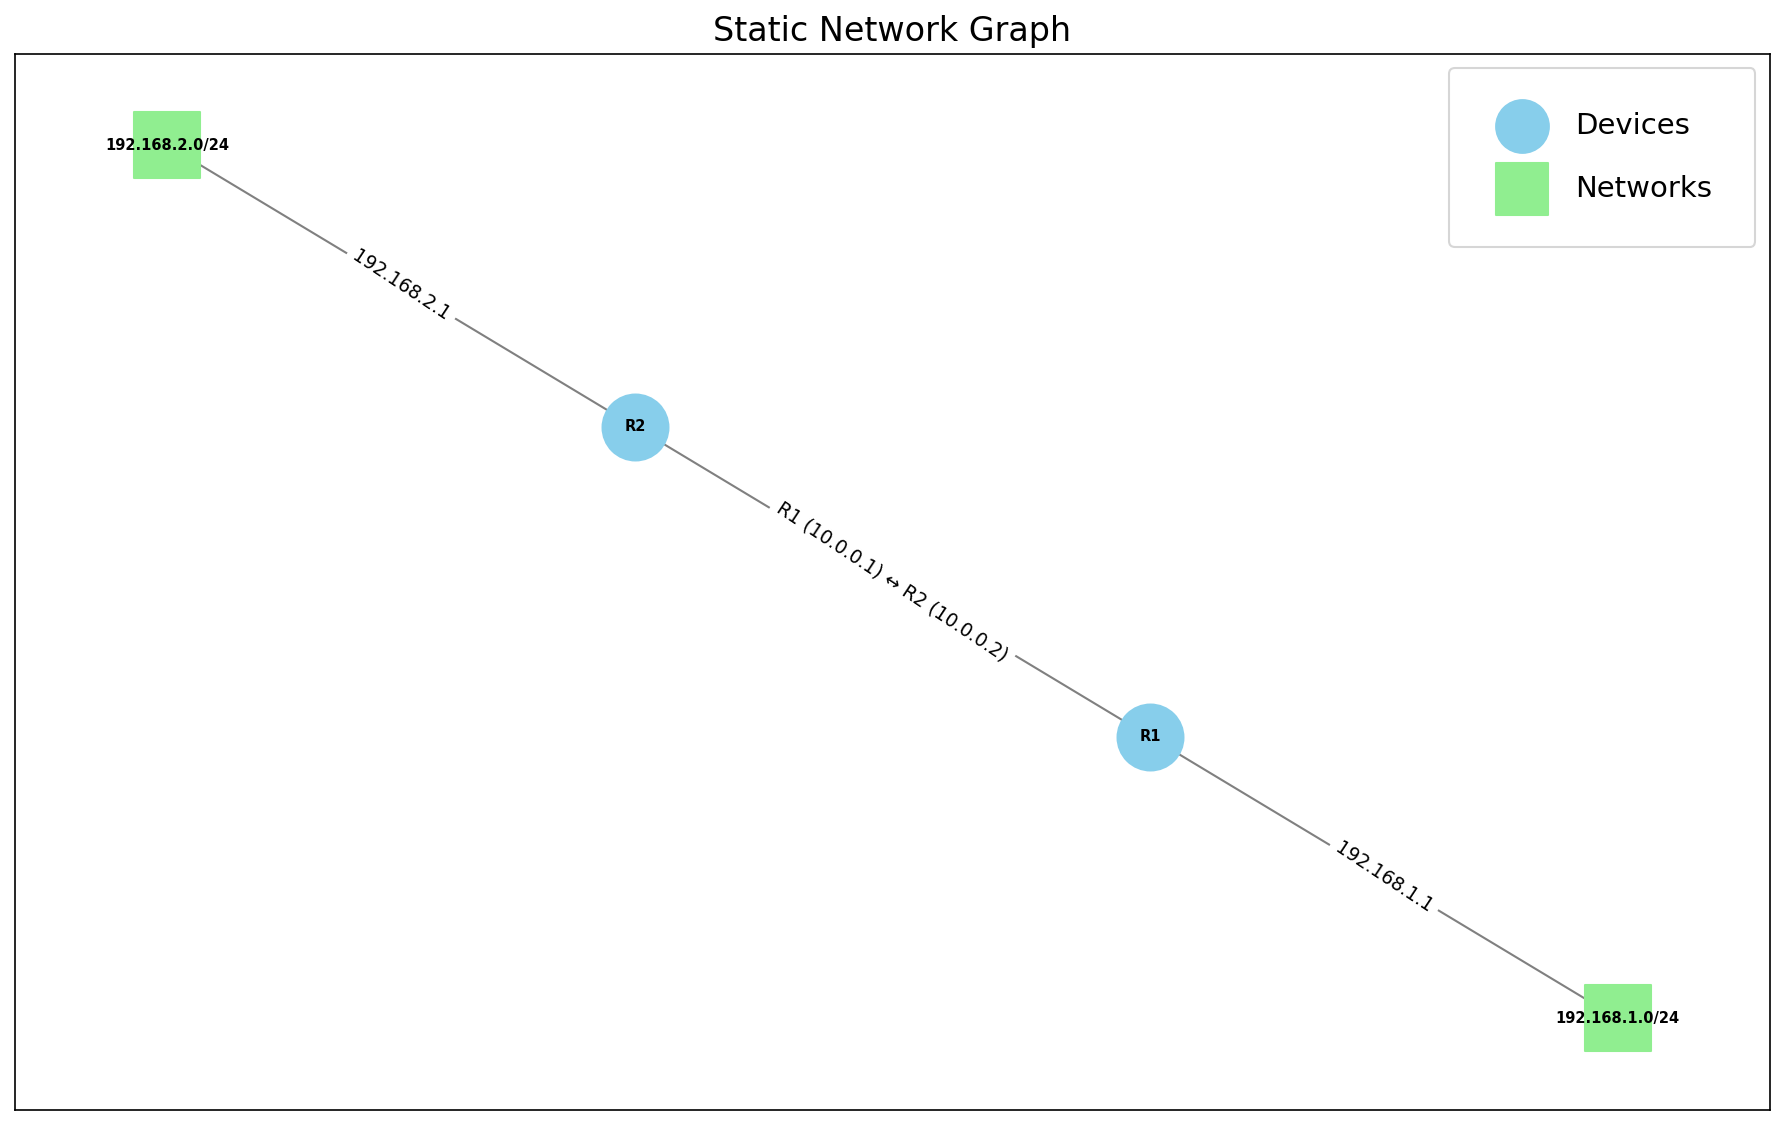

In [116]:
draw_static_network_graph(G)

In [117]:
draw_dynamic_network_graph(G)

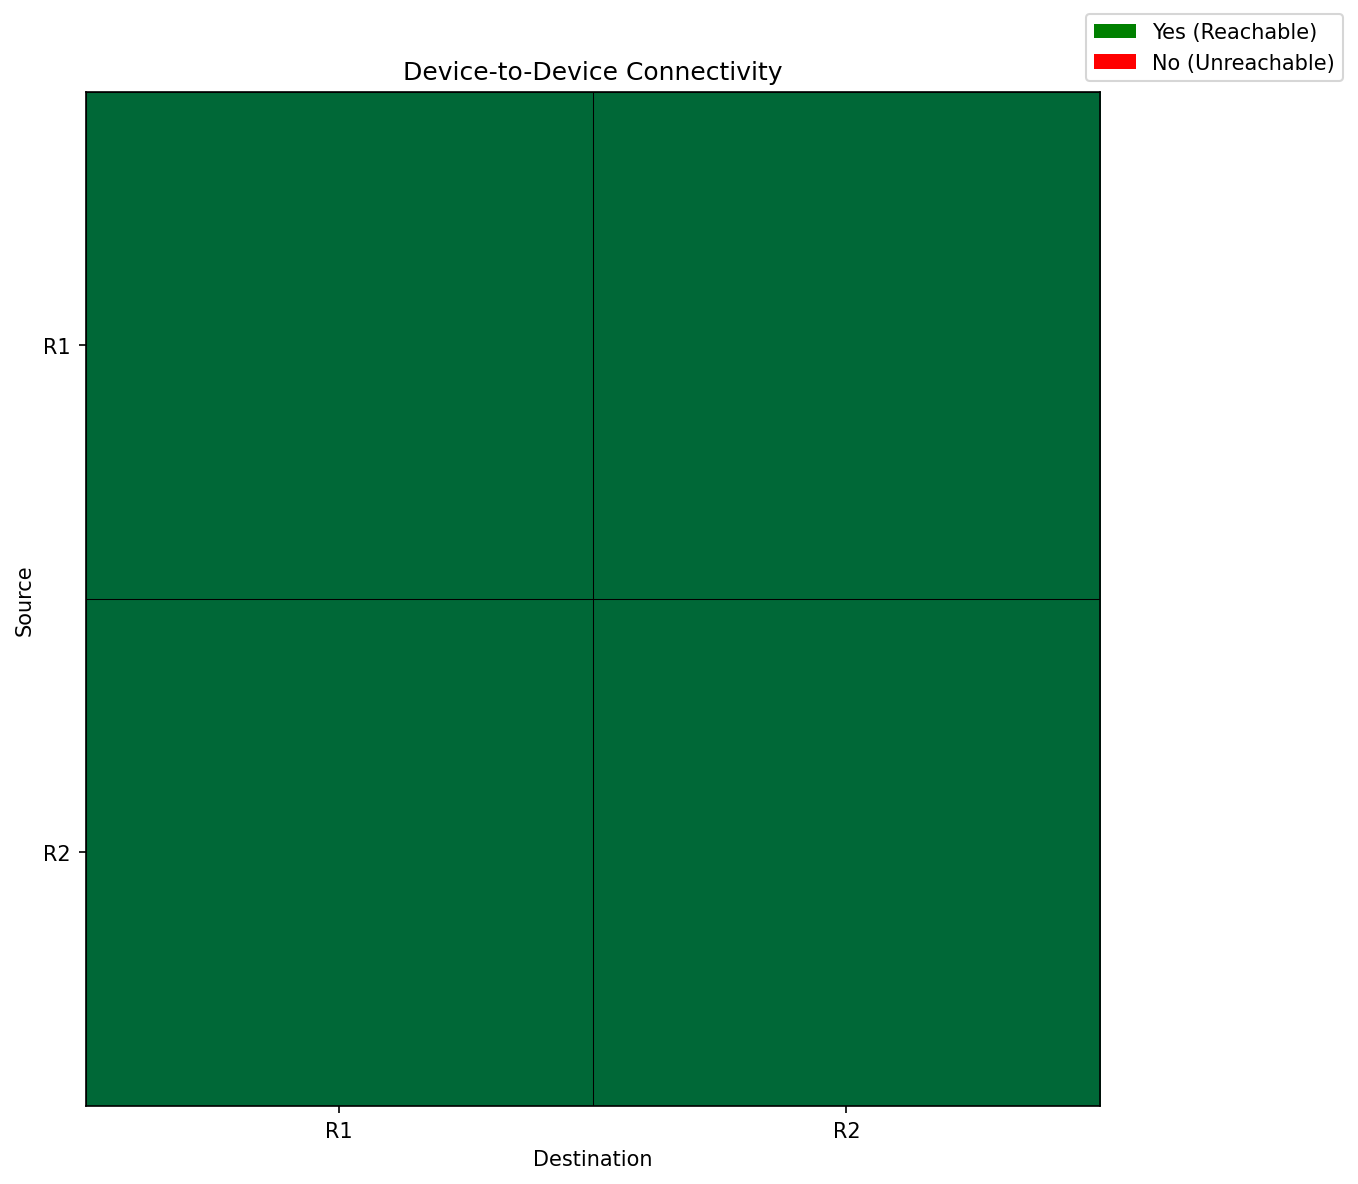

In [118]:
check_device_connectivity(G)

### Example 2
The backbone network is divided into multiple /30 subnets, each representing a point-to-point link between two routers. Each /30 subnet provides four addresses: a network address, two usable IPs (assigned to the connected routers), and a broadcast address. For example, the...
- 10.0.0.0/30 subnet connects R1 and R2 using 10.0.0.1 and 10.0.0.2
- 10.0.0.4/30 subnet connectes R2 and R3 with usable addresses 10.0.0.5 and 10.0.0.6
- 10.0.0.8/30 subnet connects R3 and R4 with usable addresses 10.0.0.9 and 10.0.0.10
- 10.0.0.12/30 subnet connects R4 and R1 with usable addresses 10.0.0.13 and 10.0.0.14     

This design ensures that each router-to-router link is isolated in its own subnet, optimizing IP usage and reflecting standard practices for point-to-point backbone connections. For the access / edge layer, let's assign the IP addresses, like so:
* 192.168.1.0/24 subnet connects R1 and R5 using 192.168.1.1 and 192.168.1.2
* 192.168.2.0/24 subnet connects R1 and R6 using 192.168.2.1 and 192.168.2.2
* 192.168.3.0/24 subnet connects R2 and R7 using 192.168.3.1 and 192.168.3.2
* 192.168.4.0/24 subnet connects R2 and R8 using 192.168.4.1 and 192.168.4.2
* 192.168.5.0/24 subnet connects R3 and R9 using 192.168.5.1 and 192.168.5.2
* 192.168.6.0/24 subnet connects R3 and R10 using 192.168.6.1 and 192.168.6.2
* 192.168.7.0/24 subnet connects R4 and R11 using 192.168.7.1 and 192.168.7.2
* 192.168.8.0/24 subnet connects R4 and R12 using 192.168.8.1 and 192.168.8.2


In [119]:
G = build_network_graph("device_config2.json")

devices = {}
for node, data in G.nodes(data=True):
    if data.get("type") == "device":
        devices[node] = driver(hostname=node)

# Provision devices
provision_devices(devices, "device_config2.json")
generate_report(devices)

# Show live device state (important for demo proof)
print("LIVE DEVICE STATE CHECK")

for name, device in devices.items():
    print(f"\n--- {name} ---")
    print("FACTS:")
    display(device.get_facts())

    print("\nINTERFACES:")
    display(device.get_interfaces())

# Generate report
generate_report(devices, "network_report2.json")


===== PROVISIONING DEVICES =====

[R1] load_merge_candidate()
[R1] compare_config()

[R1] CONFIG DIFF:
+ hostname R1-Core
+ interface eth0
+ ip address 10.0.0.1/30
+ interface eth1
+ ip address 10.0.0.14/30
+ interface eth2
+ ip address 192.168.1.1/24
+ interface eth3
+ ip address 192.168.2.1/24
[R1] commit_config()

[R2] load_merge_candidate()
[R2] compare_config()

[R2] CONFIG DIFF:
+ hostname R2-Core
+ interface eth0
+ ip address 10.0.0.2/30
+ interface eth1
+ ip address 10.0.0.5/30
+ interface eth2
+ ip address 192.168.3.1/24
+ interface eth3
+ ip address 192.168.4.1/24
[R2] commit_config()

[R3] load_merge_candidate()
[R3] compare_config()

[R3] CONFIG DIFF:
+ hostname R3-Core
+ interface eth0
+ ip address 10.0.0.6/30
+ interface eth1
+ ip address 10.0.0.9/30
+ interface eth2
+ ip address 192.168.5.1/24
+ interface eth3
+ ip address 192.168.6.1/24
[R3] commit_config()

[R4] load_merge_candidate()
[R4] compare_config()

[R4] CONFIG DIFF:
+ hostname R4-Core
+ interface eth0
+ ip ad

{'hostname': 'R1', 'vendor': 'mock_napalm_driver', 'config_lines': 9}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '10.0.0.1/30'},
 'eth1': {'is_up': True, 'ip': '10.0.0.14/30'},
 'eth2': {'is_up': True, 'ip': '192.168.1.1/24'},
 'eth3': {'is_up': True, 'ip': '192.168.2.1/24'}}


--- R2 ---
FACTS:


...

{'eth0': {'is_up': True, 'ip': '192.168.7.2/24'},
 'eth1': {'is_up': True, 'ip': None}}


--- R12 ---
FACTS:


{'hostname': 'R12', 'vendor': 'mock_napalm_driver', 'config_lines': 3}


INTERFACES:


{'eth0': {'is_up': True, 'ip': '192.168.8.2/24'},
 'eth1': {'is_up': True, 'ip': None}}

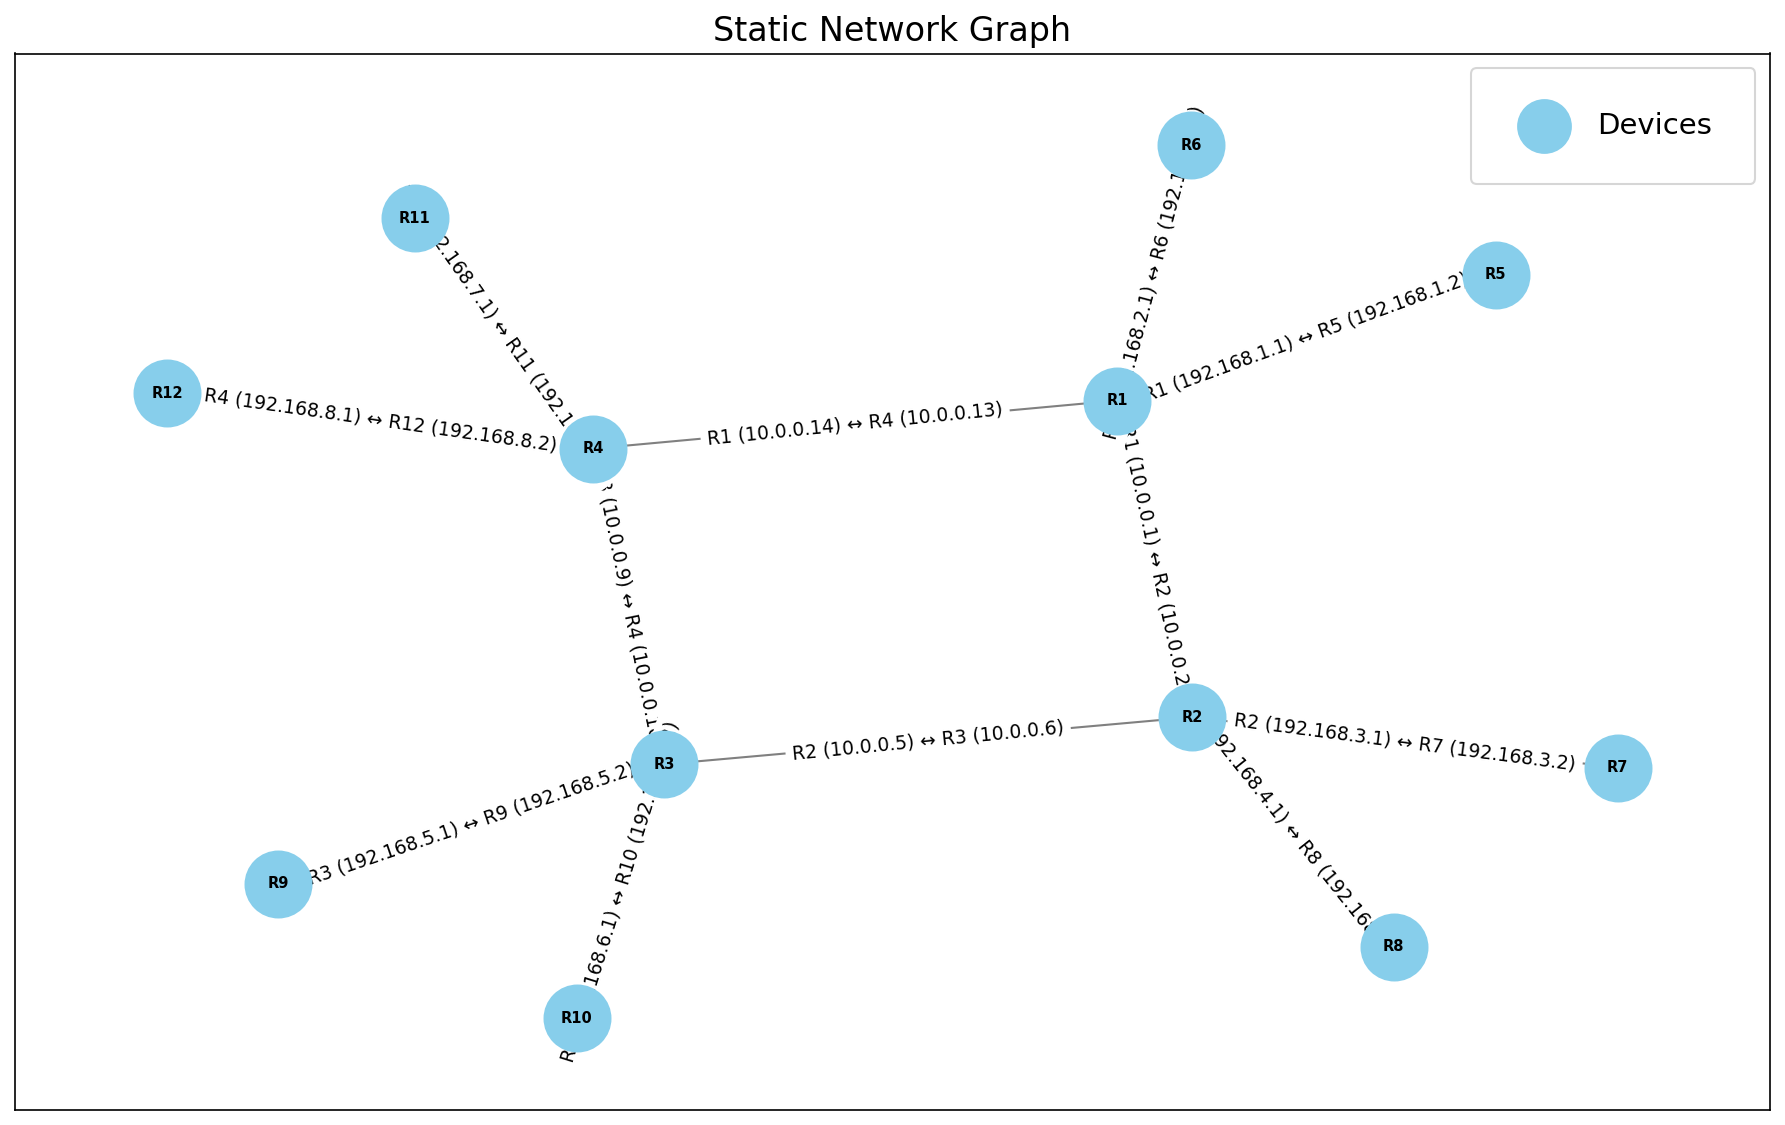

In [120]:
draw_static_network_graph(G)

In [121]:
draw_dynamic_network_graph(G)

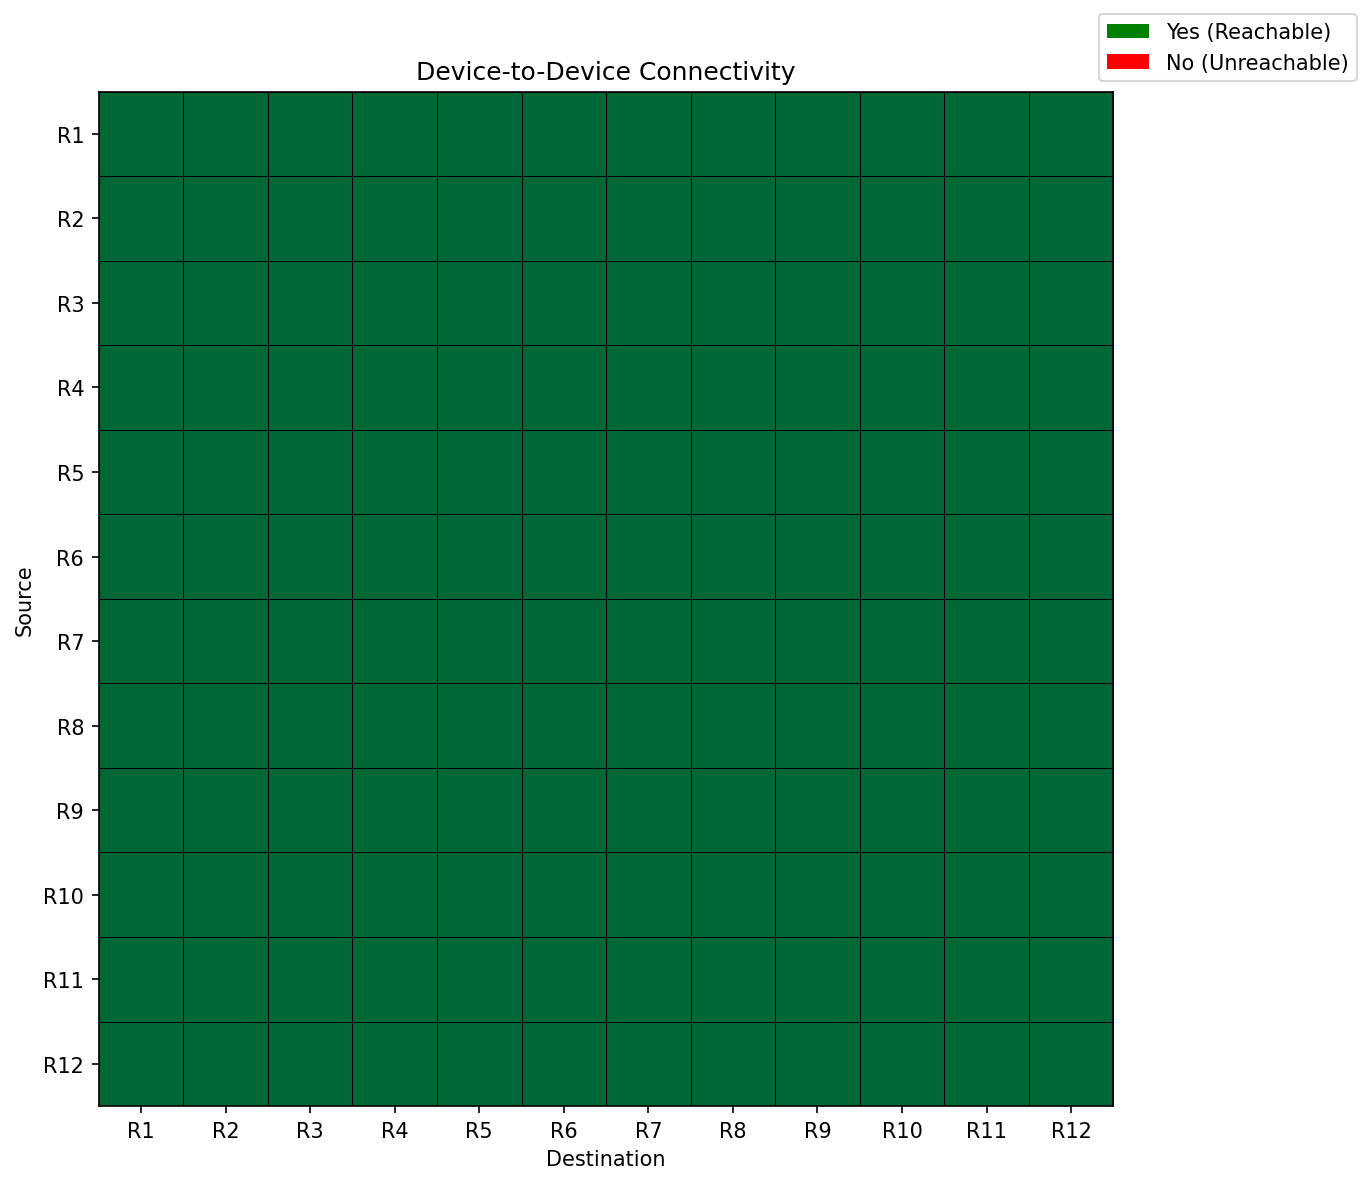

In [95]:
check_device_connectivity(G)

## Summary and Conclusion (Will, rewrite this AI)

This project presents a Python-based network automation simulation inspired by the NAPALM framework, designed to bridge the gap between theoretical networking concepts and practical automation workflows. The system allows users to define network topologies and device configurations through structured JSON files, which are then dynamically parsed within a Jupyter Notebook environment to generate a graph-based representation of the network. A custom-built mock `driver` class replicates key NAPALM functionalities such as configuration staging, committing changes, and retrieving device state, enabling users to simulate realistic automation tasks without requiring access to physical or virtual network hardware.

The methodology combines configuration-driven topology generation, graph-based modeling using NetworkX, and both static and interactive visualizations to provide multiple perspectives of the network. Static graphs offer a quick overview of structure and connectivity, while interactive Cytoscape-based views allow users to explore, manipulate, and better understand complex topologies in real time. Additionally, a device-to-device connectivity analysis tool computes reachability across the network, helping validate whether intended communication paths exist based on configuration. A reporting module further summarizes device states and interface configurations, reinforcing the automation workflow lifecycle from provisioning to validation.

Overall, the motivation behind this project is to make network automation concepts more accessible to students, educators, and aspiring network engineers who may not have access to enterprise-grade lab environments or physical infrastructure. By simulating NAPALM-like behavior in a lightweight and extensible Python environment, the project provides a practical learning platform for understanding how modern network automation tools operate. It helps learners develop both conceptual and technical skills in configuration management, topology inference, and automation logic, while also reinforcing how design decisions impact real network behavior.

In conclusion, this project demonstrates how software-based simulation can effectively replicate key aspects of modern network automation systems. It provides a clear, visual, and interactive way to understand complex network relationships while also offering hands-on experience with automation principles used in industry. Beyond its educational value, the project reflects broader industry trends toward software-defined networking and automation-first operations, helping prepare learners for real-world networking roles where tools like NAPALM, Ansible, and similar frameworks are increasingly essential.


## Distribution of Work